In [3]:
import pandas as pd
import random
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, PolynomialFeatures, MinMaxScaler
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, recall_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint
from sklearn.svm import SVC, LinearSVC


print('loaded!')


loaded!


In [4]:
data = pd.read_csv('Heart_Attack_data.csv')
print(data.info)
#print(data.head())

<bound method DataFrame.info of         HeartDiseaseorAttack  HighBP  HighChol  CholCheck   BMI  Smoker  \
0                        0.0     1.0       1.0        1.0  40.0     1.0   
1                        0.0     0.0       0.0        0.0  25.0     1.0   
2                        0.0     1.0       1.0        1.0  28.0     0.0   
3                        0.0     1.0       0.0        1.0  27.0     0.0   
4                        0.0     1.0       1.0        1.0  24.0     0.0   
...                      ...     ...       ...        ...   ...     ...   
253675                   0.0     1.0       1.0        1.0  45.0     0.0   
253676                   0.0     1.0       1.0        1.0  18.0     0.0   
253677                   0.0     0.0       0.0        1.0  28.0     0.0   
253678                   0.0     1.0       0.0        1.0  23.0     0.0   
253679                   1.0     1.0       1.0        1.0  25.0     0.0   

        Stroke  Diabetes  PhysActivity  Fruits  ...  AnyHealthcare 

In [5]:
data[data.duplicated()]

,HeartDiseaseorAttack,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
1242,0.0,1.0,1.0,1.0,27.0,1.0,0.0,2.0,0.0,0.0,...,1.0,0.0,5.0,0.0,30.0,1.0,0.0,10.0,4.0,5.0
1563,0.0,0.0,0.0,1.0,21.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,4.0,6.0,8.0
2700,0.0,0.0,0.0,1.0,32.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,5.0,6.0,8.0
3160,0.0,0.0,0.0,1.0,21.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,4.0,6.0,8.0
3332,0.0,0.0,0.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,9.0,6.0,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253492,0.0,1.0,1.0,1.0,33.0,0.0,0.0,2.0,1.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,9.0,6.0,6.0
253550,0.0,0.0,0.0,1.0,25.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,7.0,6.0,8.0
253563,0.0,0.0,1.0,1.0,24.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,1.0,8.0,6.0,8.0
253597,0.0,0.0,0.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,5.0,6.0,8.0


While there are duplicate records I don't think we can drop any as there are no unique identifiers.
It's a very real possibility that with 250,000+ records there are multiple people with same stats

In [6]:
#data['HeartDiseaseorAttack'].value_counts()
data['HeartDiseaseorAttack'].value_counts(0) / len(data['HeartDiseaseorAttack'])

# 90.5% have no heart disease
# 0.094% do

HeartDiseaseorAttack
0.0    0.905814
1.0    0.094186
Name: count, dtype: float64

In [7]:
# Check for missing data indicates none missing
print(data.isna().any())
print(data.shape)

HeartDiseaseorAttack    False
HighBP                  False
HighChol                False
CholCheck               False
BMI                     False
Smoker                  False
Stroke                  False
Diabetes                False
PhysActivity            False
Fruits                  False
Veggies                 False
HvyAlcoholConsump       False
AnyHealthcare           False
NoDocbcCost             False
GenHlth                 False
MentHlth                False
PhysHlth                False
DiffWalk                False
Sex                     False
Age                     False
Education               False
Income                  False
dtype: bool
(253680, 22)


In [8]:
# datatype check for scaling later
for col in data.columns:
    print(col, data[col].nunique(), data[col].unique()[:5])

HeartDiseaseorAttack 2 [0. 1.]
HighBP 2 [1. 0.]
HighChol 2 [1. 0.]
CholCheck 2 [1. 0.]
BMI 84 [40. 25. 28. 27. 24.]
Smoker 2 [1. 0.]
Stroke 2 [0. 1.]
Diabetes 3 [0. 2. 1.]
PhysActivity 2 [0. 1.]
Fruits 2 [0. 1.]
Veggies 2 [1. 0.]
HvyAlcoholConsump 2 [0. 1.]
AnyHealthcare 2 [1. 0.]
NoDocbcCost 2 [0. 1.]
GenHlth 5 [5. 3. 2. 4. 1.]
MentHlth 31 [18.  0. 30.  3.  5.]
PhysHlth 31 [15.  0. 30.  2. 14.]
DiffWalk 2 [1. 0.]
Sex 2 [0. 1.]
Age 13 [ 9.  7. 11. 10.  8.]
Education 6 [4. 6. 3. 5. 2.]
Income 8 [3. 1. 8. 6. 4.]


In [9]:
'''
Check different types of machine learning models to see which ones identify Heart Disease Risk Best

Will be using Recall as our metric as it's more important to catch all positives with some false-positives rather than have false-negatives
'''
scoring_type = 'recall'
results = []

In [10]:
# Preprocess Data. Identify binary, ordinal, continuous variables

binary_features = [
    'HighBP','HighChol','CholCheck','Smoker','Stroke',
    'PhysActivity','Fruits','Veggies','HvyAlcoholConsump',
    'AnyHealthcare','NoDocbcCost','DiffWalk','Sex'
]

ordinal_features = [
    'Diabetes','GenHlth','Age','Education','Income','MentHlth','PhysHlth'
]

continuous_features = [
    'BMI'
]

# change binary columns to ints
data[binary_features] = data[binary_features].astype(int)

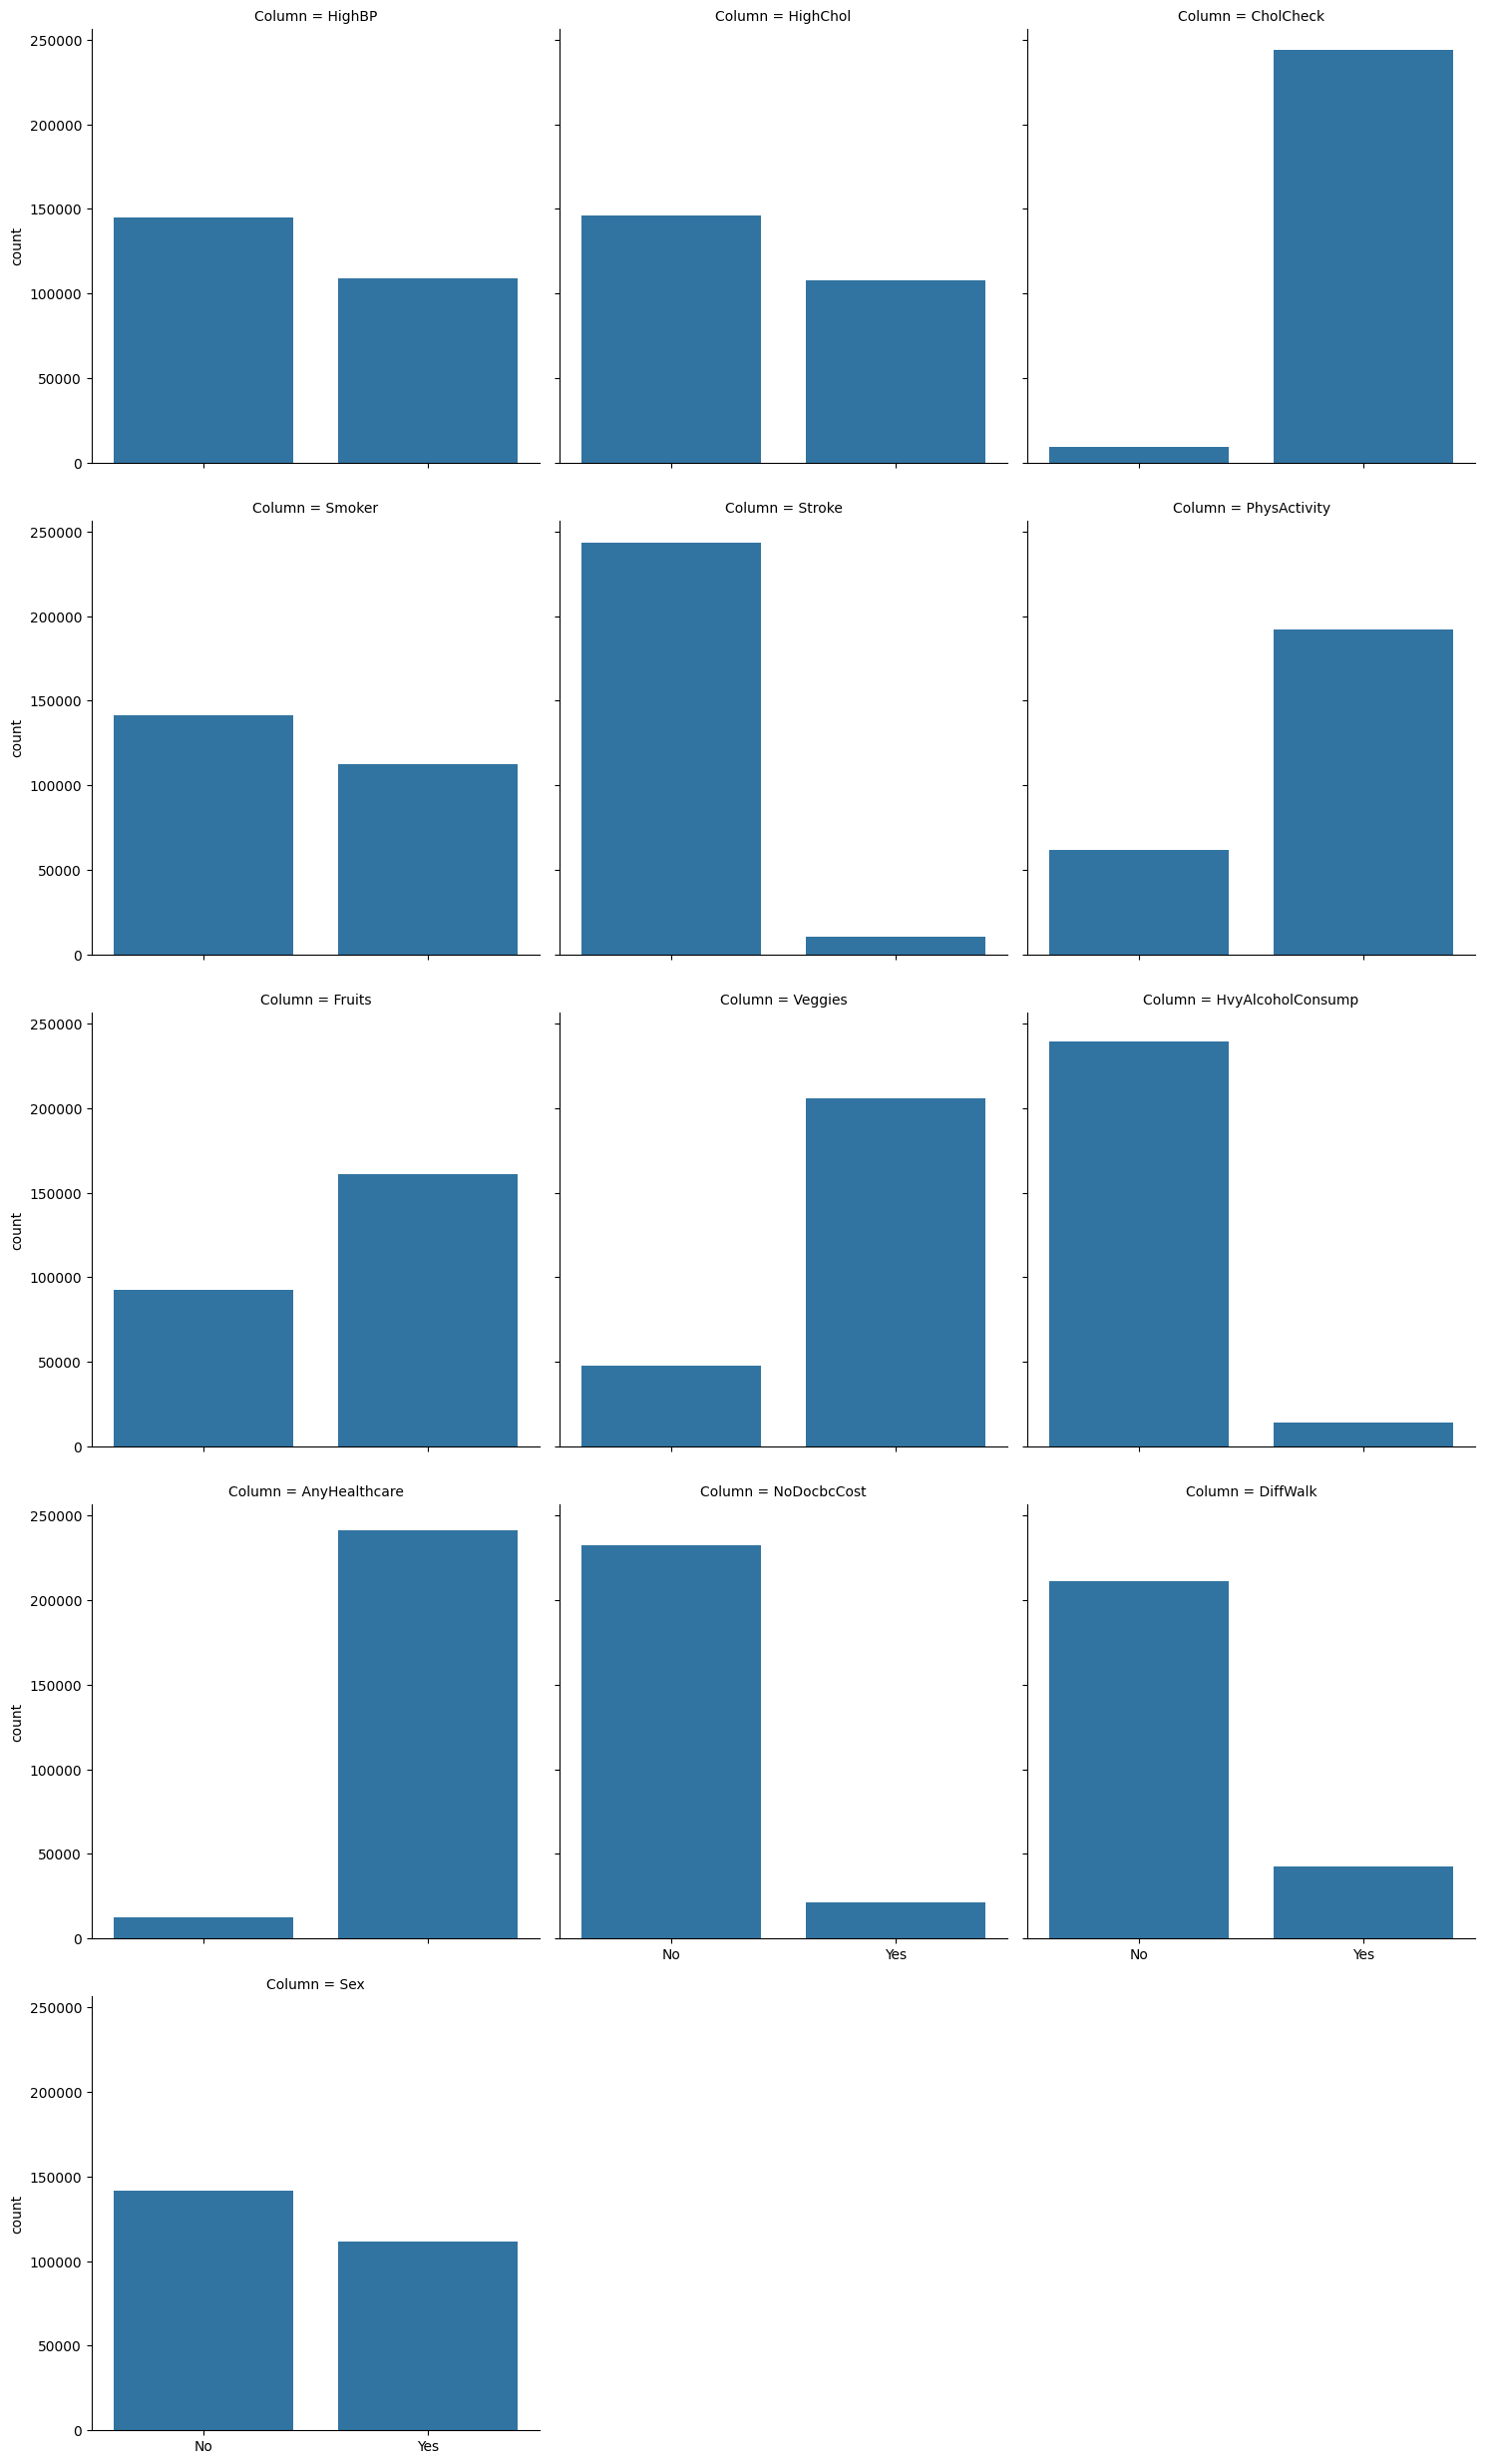

<Axes: ylabel='Count'>

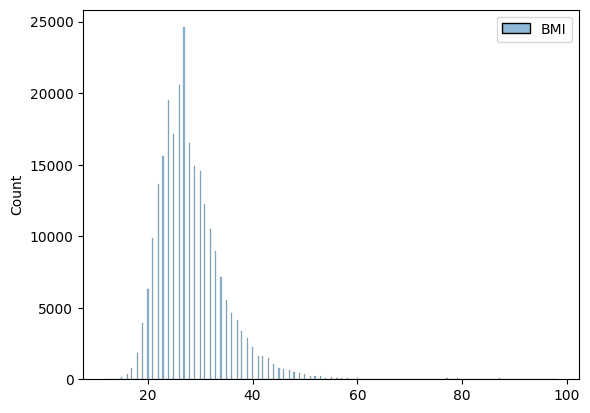

In [11]:
# Check for distribution of variables

# Binary Variables
df_long = pd.melt(data[binary_features], value_vars = binary_features, var_name = 'Column', value_name = 'Value')
g = sns.catplot(
    data = df_long, 
    x = 'Value',
    col = 'Column',
    kind = 'count', 
    col_wrap = 3,
    sharex=True
)

for ax in g.axes.flat:
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['No', 'Yes'])
g.set_xlabels('')
plt.show()


# Continuous
sns.histplot(data[continuous_features])

In [12]:
# split and scale BMI
X = data.drop(columns=['HeartDiseaseorAttack'])
y = data['HeartDiseaseorAttack']

# split data into train_test. test size = 20%. Stratify to ensure proper distribution because of imbalanced dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42, test_size=.2,stratify = y)
print(X_train.shape, X_test.shape)

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

y_train = y_train.values.ravel()
y_test = y_test.values.ravel()

# scale BMI
scaler = StandardScaler()
X_train_scaled[['BMI']] = scaler.fit_transform(X_train[['BMI']])
X_test_scaled[['BMI']] = scaler.transform(X_test[['BMI']])

(202944, 21) (50736, 21)


In [13]:
''' 
Now that we are properly scaled and validated we can look at model testing and selection

Models to choose from: logistic regression, SVM, Decision Tree, Random Forest
'''

' \nNow that we are properly scaled and validated we can look at model testing and selection\n\nModels to choose from: logistic regression, SVM, Decision Tree, Random Forest\n'

# Logistic Regression

Training set recall is: 0.7935
Test set recall is: 0.7972


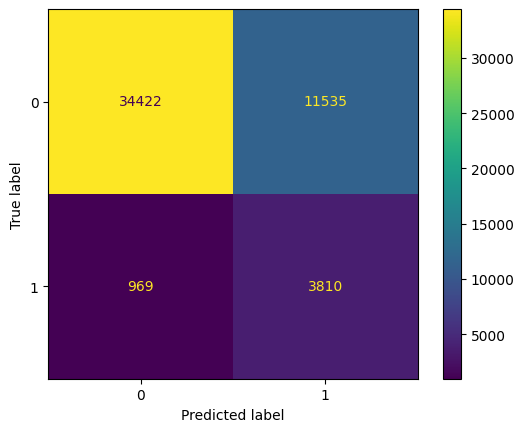

In [14]:
# Log-Reg
lasso = LogisticRegression(max_iter = 10000,solver = "liblinear", random_state = 123, class_weight='balanced')
lasso.fit(X_train_scaled, y_train)

# training_set prediction to check
y_train_pred = lasso.predict(X_train_scaled)
log_reg_train_recall = recall_score(y_train, y_train_pred)
print(f'Training set recall is: {round(log_reg_train_recall, 4)}')

# predict
y_log_pred = lasso.predict(X_test_scaled)

# confusion_matrix to check
lr_cm = confusion_matrix(y_test, y_log_pred)
ConfusionMatrixDisplay(lr_cm).plot()

# recall score
log_reg_recall = recall_score(y_test, y_log_pred)
print(f'Test set recall is: {round(log_reg_recall, 4)}')

# f1 score
f1 = f1_score(y_test, y_log_pred)

results.append({
    'Model': 'Logistic Regression', 
    'Recall': log_reg_recall,
    'f1': f1,
    'ROC-AUC': roc_auc_score(y_test, y_log_pred)
})

# SVM - Support Vector Machine

In [15]:
# Create SVM model
svm_model = SVC(
    kernel="rbf",
    class_weight="balanced",
    probability=False,   
    max_iter=1000
)

# fit the model to scaled training set
svm_model.fit(X_train_scaled, y_train)

# Check training set recall - not very valuable as it fits perfectly
y_train_svm_pred = svm_model.predict(X_train_scaled)
y_svm_recall_train = recall_score(y_train, y_train_svm_pred)
print(f'SVM Recall on Training set is: {y_svm_recall_train}')

# test_set recall
y_test_svm_pred = svm_model.predict(X_test_scaled)
y_test_svm_recall = recall_score(y_test, y_test_svm_pred)
print(y_test_svm_recall)

''' 
We are getting 1.0 Recall for both, highly unrealistic.
It's most likely because it's just predicting positives for everything.
Let's check a Confusion Matrix
'''

C:\Users\crees\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\svm\_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


SVM Recall on Training set is: 1.0


KeyboardInterrupt: 

(array([1.]), array([50736]))


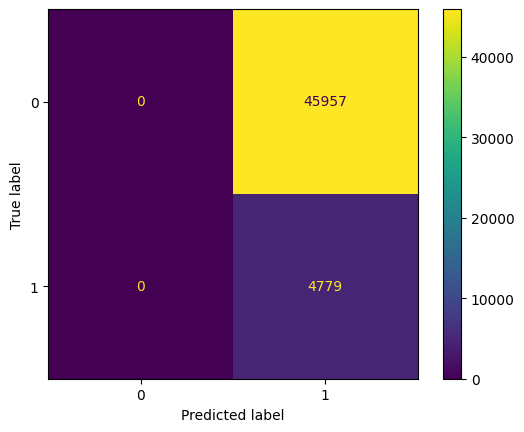

In [ ]:
import numpy as np
print(np.unique(y_test_svm_pred, return_counts=True))

# confusion_matrix to check
svm_cm = confusion_matrix(y_test, y_test_svm_pred)
ConfusionMatrixDisplay(svm_cm).plot()

# We can confirm it's just predicting positives for everything. 

RBF SVM with default settings (and class weighting) is not working well on this set. I can check with a linear SVM as well.

In [ ]:
# Linear SVM
linear_svm_model = LinearSVC(
    class_weight='balanced',
    max_iter=5000,
    random_state=42
)

# fit the model
linear_svm_model.fit(X_train_scaled, y_train)

# predict on training for base
y_train_linsvm_pred = linear_svm_model.predict(X_train_scaled)
train_linsvm_recall = recall_score(y_train, y_train_linsvm_pred)
print(train_linsvm_recall)

# predict on test set
linsvm_pred_y_test = linear_svm_model.predict(X_test_scaled)
linsvm_test_recall = recall_score(y_test,linsvm_pred_y_test)
print(linsvm_test_recall)

f1 = f1_score(y_test, linsvm_pred_y_test)

results.append({
    'Model': 'Linear SVM',
    'Recall': linsvm_test_recall,
    'f1': f1,
    'ROC-AUC': roc_auc_score(y_test, linsvm_pred_y_test)
})

confusion_matrix(y_test, linsvm_pred_y_test)

0.8004603955216072
0.802887633396108


array([[34119, 11838],
       [  942,  3837]])

# Random Forest Classifier

In [ ]:
# Random Forest
# Cross Validation

# Need to perform some parameter tuning using gridsearch
rfclassifier= RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced')
params = {'max_depth': [5, 10],
    'n_estimators': [200, 400],
    'min_samples_split': [2, 5]
}

clf = RandomizedSearchCV(estimator=rfclassifier,
                    param_distributions=params,
                    n_iter=20,
                    cv=3,
                    scoring=scoring_type,
                    n_jobs=-1,
                    verbose=2,
                    random_state=42
)

# Fit the GridSearchCV model
clf.fit(X_train, y_train)

# Print the best hyperparameters found by RandomizedsearchCV
print("Best parameters:", clf.best_params_)

# Printing best score
print(f'{scoring_type} score is: {clf.best_score_}')

best_model = clf.best_estimator_

y_pred = best_model.predict(X_test)
rf_recall = recall_score(y_test, y_pred)
print(rf_recall)

f1 = f1_score(y_test, y_pred)

results.append({
    'Model': 'Random Forest',
    'Recall': rf_recall,
    'f1': f1,
    'ROC-AUC': roc_auc_score(y_test, y_pred)
})

Fitting 3 folds for each of 8 candidates, totalling 24 fits


C:\Users\crees\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 8 is smaller than n_iter=20. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best parameters: {'n_estimators': 400, 'min_samples_split': 2, 'max_depth': 5}
recall score is: 0.8074708175768596
0.8166980539861896


---
---

# Results DataFrame

In [16]:
results_df = pd.DataFrame(results)
print(results_df)

                 Model    Recall        f1   ROC-AUC
0  Logistic Regression  0.797238  0.378652  0.773121


All 3 are very close in ROC-AUC with:  .77, .77, and .76

All 3 are very similar in f1 score as well: .38, .37, .36

Recall is close as well with: .80, .80, and .82

With the importance of not missing any true-positives I like using Random Forest the most.
With that said, the simplicity of Logistic Regression when explaining to someone is a big plus. 

I want to use the Random Forest Model to now look at the importance of each feature. 

# Random Forest Feature Importance

In [17]:
rf_feature_importance = best_model.feature_importances_
df = pd.DataFrame(zip(X.columns, rf_feature_importance), columns = ['Predictors', 'Importance'])
df = df.sort_values(by = 'Importance', ascending=False)
print(df)
# top 3: GenHlth, Age, HighBP
# This makes me worried about any multicollinearity amonst the data set. Someone with General Low Health may not exercise or eat well and thus have Higher BP

NameError: name 'best_model' is not defined

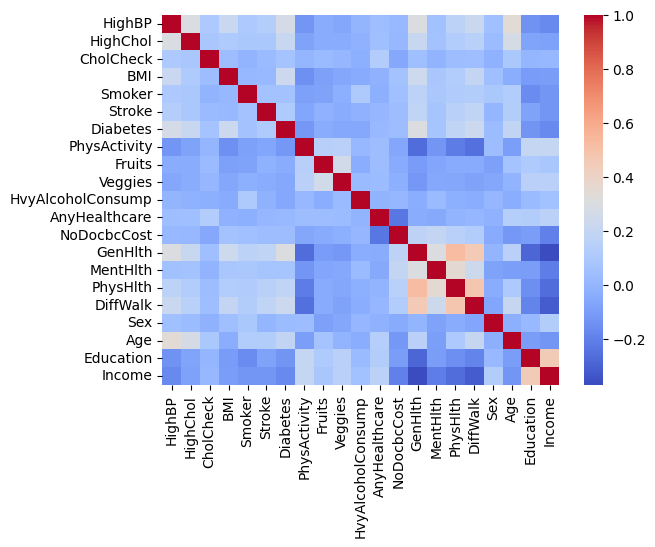

In [ ]:
# check for correlation between variables

import seaborn as sns
import matplotlib.pyplot as plt
corr_matrix = X.corr()
sns.heatmap(corr_matrix, annot = False, cmap = 'coolwarm')
plt.show()

# Nothing major, PhysHlth & GenHlth, DiffWalk & GenHlth are the 2 biggest

Income                 -0.141011
Education              -0.099600
PhysActivity           -0.087299
Veggies                -0.039167
HvyAlcoholConsump      -0.028991
Fruits                 -0.019790
AnyHealthcare           0.018734
NoDocbcCost             0.031000
CholCheck               0.044206
BMI                     0.052904
MentHlth                0.064621
Sex                     0.086096
Smoker                  0.114441
Diabetes                0.180272
HighChol                0.180765
PhysHlth                0.181698
Stroke                  0.203002
HighBP                  0.209361
DiffWalk                0.212709
Age                     0.221618
GenHlth                 0.258383
HeartDiseaseorAttack    1.000000
Name: HeartDiseaseorAttack, dtype: float64


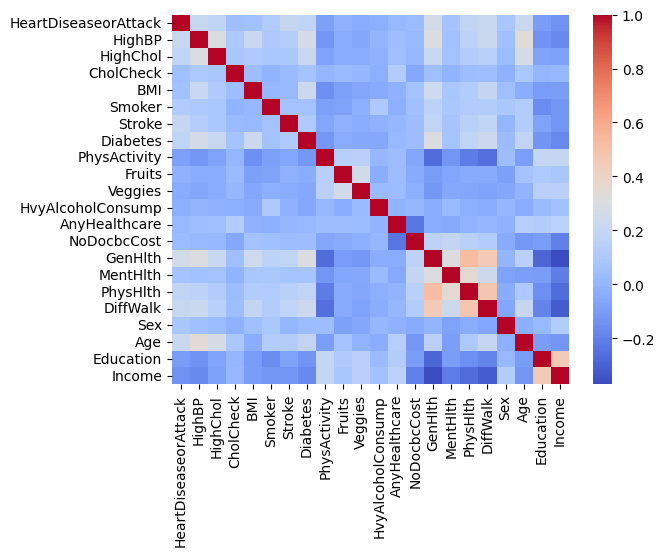

In [ ]:
all_corr = data.corr()
print(all_corr['HeartDiseaseorAttack'].sort_values())
sns.heatmap(all_corr, cmap = 'coolwarm')
plt.show()


---
---

# Prep for Dashboard

(23893, 22)
Age
10.0    4193
13.0    4159
11.0    3947
9.0     3358
12.0    3093
8.0     2253
7.0     1425
6.0      712
5.0      351
4.0      193
3.0      126
2.0       54
1.0       29
Name: count, dtype: int64
Income
8.0    4585
6.0    3646
7.0    3404
5.0    3161
4.0    2828
3.0    2519
2.0    2197
1.0    1553
Name: count, dtype: int64


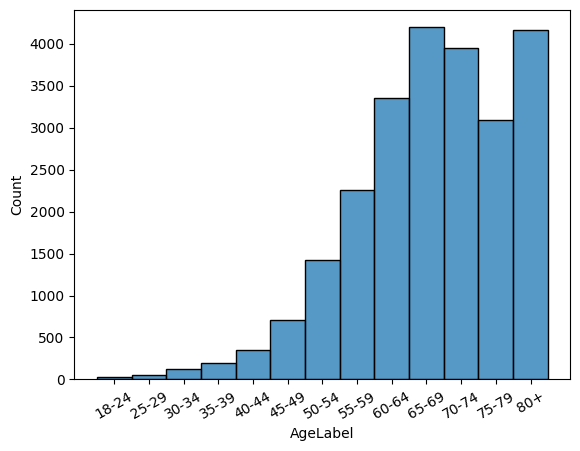

In [ ]:
# Power BI - Utilize only those that did have a heart attack
df = data[data['HeartDiseaseorAttack']==1].copy()
print(df.shape)

# check counts
print(df['Age'].value_counts())

# update age column
age_order = [
    "18-24", "25-29", "30-34", "35-39",
    "40-44", "45-49", "50-54", "55-59",
    "60-64", "65-69", "70-74", "75-79", "80+"
]
age_map = {
    1:"18-24", 2:"25-29", 3:"30-34", 4:"35-39",
    5:"40-44", 6:"45-49", 7:"50-54", 8:"55-59",
    9:"60-64", 10:"65-69", 11:"70-74", 12:"75-79", 13:"80+"
}
df['AgeLabel'] = df['Age'].map(age_map)
df['AgeLabel'] = pd.Categorical(
    df['AgeLabel'],
    categories=age_order,
    ordered=True,   
)

age_hist = sns.histplot(df["AgeLabel"])
plt.xticks(rotation = 30)

print(df['Income'].value_counts())
# update income
income_order = [
    '<$10,000', '$10,000-$14,999', '$15,000-$19,999',
    '$20,000-$24,999', '$25,000-$34,999', '$35,000-$49,999',
    '$50,000-$74,999', '$75,000 +'
]
income_map = {
    1: '<$10,000', 2: '$10,000-$14,999', 3: '$15,000-$19,999',
    4: '$20,000-$24,999', 5:'$25,000-$34,999', 6: '$35,000-$49,999',
    7: '$50,000-$74,999', 8:'$75,000 +'
}

df['IncomeLabel'] = df['Income'].map(income_map)
df['IncomeLabel'] = pd.Categorical(
    df['IncomeLabel'],
    categories = income_order,
    ordered = True,
)

# HighBp Label
df['HighBPLabel'] = df['HighBP'].map({
    1: 'Yes',
    0: 'No'
})

# Walk Label
df['DiffWalkLabel'] = df['DiffWalk'].map({
    1: 'Yes',
    0: 'No'
})

# GenHlth Labels
df['GenHlthLabels'] = df['GenHlt'].map({
    1: 'Excellent', 2: 'Great',
    3: 'Average', 4: 'Below Avg', 5: 'Poor'
})

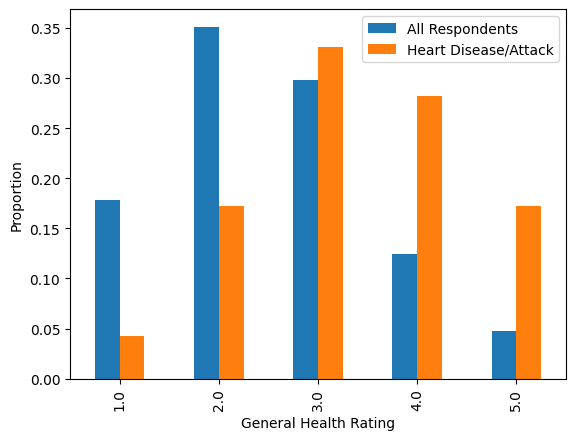

In [19]:
genhlth_all = data['GenHlth'].value_counts(normalize=True).sort_index()
genhlth_hd = df['GenHlth'].value_counts(normalize=True).sort_index()

comparison = pd.DataFrame({
    'All Respondents': genhlth_all,
    'Heart Disease/Attack': genhlth_hd
})

comparison.plot(kind='bar')
plt.ylabel("Proportion")
plt.xlabel("General Health Rating")
plt.show()

In [20]:
print(df['HighBP'].value_counts())
df['HighBP'].value_counts(normalize=True)

HighBP
1    17928
0     5965
Name: count, dtype: int64


HighBP
1    0.750345
0    0.249655
Name: proportion, dtype: float64

In [26]:
HDoA = df[['HighBPLabel', 'HighBP', 'Age','AgeLabel', 'GenHlth', 'HighChol', 'DiffWalk', 'IncomeLabel', 'Smoker', 'HvyAlcoholConsump', 'Veggies']]
print(HDoA.shape)

HDoA.to_csv('HDoA.csv', index = False)

(23893, 11)


In [30]:
print(df['DiffWalk'].value_counts()
      )
df['DiffWalk'].apply(type).value_counts()
df['DiffWalk'].unique()

DiffWalk
0    13978
1     9915
Name: count, dtype: int64


array([1, 0])